## Загрузка данных, схема, sanity-чеки, агрегация на уровень магазина, симуляция cold-start holdout

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [5]:
NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR / 'data'

In [6]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"NOTEBOOK_DIR: {NOTEBOOK_DIR}")
print(f"DATA_DIR: {DATA_DIR}")

NOTEBOOK_DIR: /Users/alexey_macos/Documents/ITjob/Pet-projects/Magnit_retailhack_2026/notebooks
DATA_DIR: /Users/alexey_macos/Documents/ITjob/Pet-projects/Magnit_retailhack_2026/data


In [21]:
def read_data(path):
    df = (pd.read_csv(path, encoding="utf-8-sig", skipinitialspace=True)
            .rename(columns=lambda c: c.strip().upper()))

    for col in df.columns:
        if df[col].dtype != "object":
            continue  # уже числовой или явно нечисловой — не трогаем

        # пробуем починить: убрать пробелы-разделители тысяч + запятая→точка
        cleaned = (df[col].astype(str)
                          .str.replace(r"\s+", "", regex=True)   # "1 000 000" → "1000000"
                          .str.replace(",", ".", regex=False))    # "1,5" → "1.5" (десятичная запятая)
        converted = pd.to_numeric(cleaned, errors="coerce")

        # критерий "это числовая колонка": после чистки <5% новых NaN
        new_nan = converted.isna().sum() - df[col].isna().sum()
        if new_nan / len(df) < 0.05:
            df[col] = converted  # принимаем как число
        # иначе оставляем как текст (REGION, CITY и т.д.)

    return df

In [22]:
train = read_data(DATA_DIR / "train.csv")

In [23]:
print("object-колонки train:", train.select_dtypes("object").columns.tolist())
print("NaN в числовых:", train.select_dtypes("number").isna().sum().sum())

object-колонки train: ['REGION', 'BRANCH', 'CITY', 'SUBJECT']
NaN в числовых: 0


In [24]:
train.columns = train.columns.str.strip()

print(train.shape)
print(train.columns.tolist())

(15109, 56)
['ID', 'REGION', 'BRANCH', 'CITY', 'SUBJECT', 'SUBFRMT', 'TRADE_SQUARE', 'HUFFFAMILIES', 'HUFFRELATIVEFAMILIES', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'ROUTES_CNT', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'HUFF_HOTEL', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE', 'DIST_TO_ADM_CENTER', 'PARKING', 'MONTH_COUNT', 'NEW_BUILDINGS', 'CHANGE_CA', 'TARGET_1', 'TARGET_2']


In [ ]:
# train = pd.read_csv(
#     DATA_DIR / "train.csv",
#     encoding="utf-8-sig",                       # для корректного чтения русских символов
#     skipinitialspace=True,                      # убирает пробелы после запятой в значениях
# ).rename(columns=lambda c: c.strip().upper())   # убираем пробелы и приводим к верхнему регистру

In [ ]:
# # Чистим имена колонок от пробелов по краям (target_2 был с пробелами)
# train.columns = train.columns.str.strip()

# print(train.shape)
# print(train.columns.tolist())

In [25]:
train.head(5)

,ID,REGION,BRANCH,CITY,SUBJECT,SUBFRMT,TRADE_SQUARE,HUFFFAMILIES,HUFFRELATIVEFAMILIES,HOSPITAL,KINDERGARTENS,BANKS,MK_ON_MM,ROUTES_CNT,CROSSWALK,CROSSROAD,DENSITY_FAMILY_TYPE,COLLEGES,HUFF_HOTEL,TRADING_PATCH_SCORE,RENT_HEX,IN_COAL_CITY,IN_OIL_CITY,CITY_TYPE,ON_DUPLICATE_ROAD,HUFF_RANK_COMPS_CANNIBALS,TOTAL_RANK_COMPS_CANNIBALS,INSIDE_YARD,ON_INSIDE_DISTRICT_ROAD,ON_MAIN_CITY_ROAD,ON_INTERCITY_HIGHWAY,ENTRANCE_TO_DISTRICT,ON_DISTRICT_BOTTOM,HUB,ALCOHOL,TOBACCO,LOCATION_MARKET,STATIONS,TRC,METRO,LOCATION_PARK,MINI_TRC,TRADING_PATCH,ENTIRE_DAY,MORNING_ROADSIDE,SEA,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,MONTH_COUNT,NEW_BUILDINGS,CHANGE_CA,TARGET_1,TARGET_2
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,0,0,0,5,1,0,1,0,0.000000,0.037696,0.100911,0,0,2,0,2,2,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,0.550733,0,318,0,0,175198.181281,174259.925193
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,0,0,0,0,1,0,3,0,0.063891,0.031414,0.229610,0,0,2,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,1.114666,0,317,0,0,360629.424460,296286.063051
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,0,0,1,0,1,0,1,0,0.000000,0.116230,0.128164,0,0,1,0,2,3,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,2,3.730973,10,315,0,0,252109.534031,250903.579740
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,1,0,0,0,1,0,2,0,0.000000,0.045026,0.105460,0,0,2,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,3,1.039118,15,314,0,0,362653.018943,351612.980992
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,0,1,0,0,1,0,3,0,0.000000,0.141361,0.112611,0,0,2,0,7,4,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,2,1.595111,0,314,0,0,295733.315193,287970.899275


In [26]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15109 entries, 0 to 15108
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          15109 non-null  int64  
 1   REGION                      15109 non-null  object 
 2   BRANCH                      15109 non-null  object 
 3   CITY                        15109 non-null  object 
 4   SUBJECT                     15109 non-null  object 
 5   SUBFRMT                     15109 non-null  int64  
 6   TRADE_SQUARE                15109 non-null  float64
 7   HUFFFAMILIES                15109 non-null  float64
 8   HUFFRELATIVEFAMILIES        15109 non-null  float64
 9   HOSPITAL                    15109 non-null  int64  
 10  KINDERGARTENS               15109 non-null  int64  
 11  BANKS                       15109 non-null  int64  
 12  MK_ON_MM                    15109 non-null  int64  
 13  ROUTES_CNT                  151

In [ ]:
# train["TARGET_1"] = pd.to_numeric(
#     train["TARGET_1"].astype(str).str.strip(),
#     errors="coerce"
# )

In [ ]:
# n_nan = train["TARGET_1"].isna().sum()
# print(f"TARGET_1 dtype: {train['TARGET_1'].dtype}, NaN: {n_nan}")
# if n_nan > 0:
#     # покажем сырые значения, которые не распарсились
#     bad = train["TARGET_1"].isna()
#     print("Проблемные строки были object — смотрим оригинал:")
#     # перечитай оригинал, чтобы увидеть что там

TARGET_1 dtype: float64, NaN: 2
Проблемные строки были object — смотрим оригинал:


In [ ]:
# # Перечитываем сырой TARGET_1 как строку
# raw = pd.read_csv(DATA_DIR / "train.csv", encoding="utf-8-sig",
#                   skipinitialspace=True).rename(columns=lambda c: c.strip().upper())

# # Индексы, где после to_numeric получился NaN
# bad_idx = train.index[train["TARGET_1"].isna()]
# print("Сырые значения TARGET_1 в проблемных строках:")
# print(raw.loc[bad_idx, "TARGET_1"].tolist())
# print("\nЭти строки целиком (ID + оба таргета):")
# print(raw.loc[bad_idx, ["ID", "TARGET_1", "TARGET_2"]])

Сырые значения TARGET_1 в проблемных строках:
['1 000 000 ', '100 000 ']

Эти строки целиком (ID + оба таргета):
          ID    TARGET_1       TARGET_2
5817    5818  1 000 000   987449.405050
11249  11250    100 000   100057.205742


In [27]:
print(train[["TARGET_1", "TARGET_2"]].describe())

             TARGET_1       TARGET_2
count    15109.000000   15109.000000
mean    266941.797040  263793.481161
std      84075.802400   84081.877586
min     100000.000000  100057.205742
25%     208185.974532  204749.192651
50%     247124.692844  244115.709531
75%     305169.979520  301946.209570
max    1000000.000000  987449.405050


In [28]:
train.loc[[5817, 11249], ["ID", "TARGET_1", "TARGET_2"]]

,ID,TARGET_1,TARGET_2
5817,5818,1000000.0,987449.405050
11249,11250,100000.0,100057.205742


In [29]:
train[train["ID"].isin([5818, 11250])][["ID", "TARGET_1", "TARGET_2"]]

,ID,TARGET_1,TARGET_2
5817,5818,1000000.0,987449.405050
11249,11250,100000.0,100057.205742


Распределения targets

In [30]:
print("=== TARGET_1 (фактические продажи) ===")
print(train["TARGET_1"].describe())
print(f"Нулей: {(train['TARGET_1'] == 0).sum()}, отрицательных: {(train['TARGET_1'] < 0).sum()}")
print(f"Skew: {train['TARGET_1'].skew():.2f}")

print("\n=== TARGET_2 (скорректированные) ===")
print(train["TARGET_2"].describe())
print(f"Нулей: {(train['TARGET_2'] == 0).sum()}, отрицательных: {(train['TARGET_2'] < 0).sum()}")
print(f"Skew: {train['TARGET_2'].skew():.2f}")

=== TARGET_1 (фактические продажи) ===
count      15109.000000
mean      266941.797040
std        84075.802400
min       100000.000000
25%       208185.974532
50%       247124.692844
75%       305169.979520
max      1000000.000000
Name: TARGET_1, dtype: float64
Нулей: 0, отрицательных: 0
Skew: 1.51

=== TARGET_2 (скорректированные) ===
count     15109.000000
mean     263793.481161
std       84081.877586
min      100057.205742
25%      204749.192651
50%      244115.709531
75%      301946.209570
max      987449.405050
Name: TARGET_2, dtype: float64
Нулей: 0, отрицательных: 0
Skew: 1.51


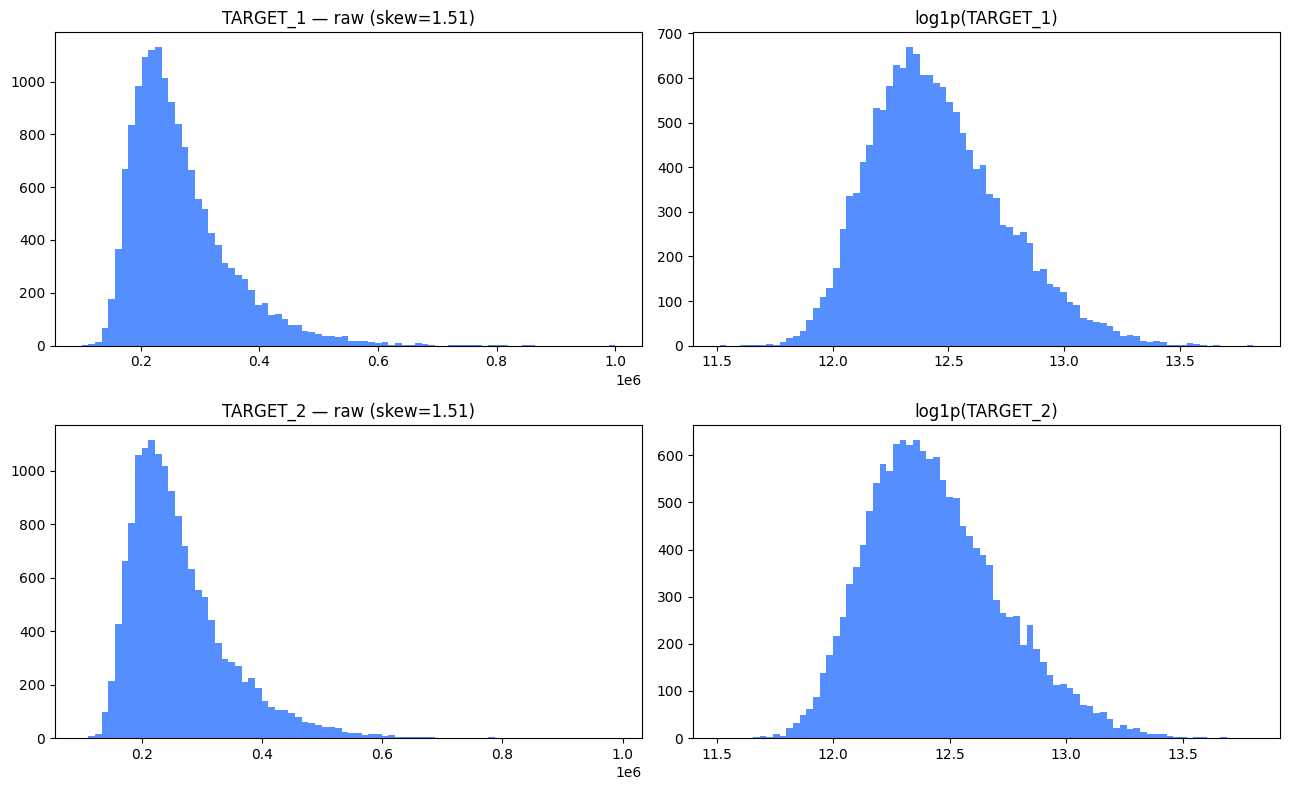

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for i, col in enumerate(["TARGET_1", "TARGET_2"]):
    # raw
    axes[i, 0].hist(train[col], bins=80, color="#0B5FFF", alpha=0.7)
    axes[i, 0].set_title(f"{col} — raw (skew={train[col].skew():.2f})")
    # log1p
    axes[i, 1].hist(np.log1p(train[col]), bins=80, color="#0B5FFF", alpha=0.7)
    axes[i, 1].set_title(f"log1p({col})")

plt.tight_layout()
plt.show()

Распределение таргетов

- Skew 1.51 оба — умеренно-правый хвост. log1p выпрямляет отлично — правые панели почти колоколообразные. → log1p оставляем, для MAPE это то что нужно.

- Нулей 0, отрицательных 0 —> MAPE не взорвётся делением на ноль.

- min = 100_000, max = 1_000_000 — диапазон в 10 раз. Узкий и аккуратный. Нет экстремальных outlayers. Это «зажатый» таргет (обрезан организаторами на границах 100k и 1M).

`Важное про min/max — вероятно clipping`

min ровно 100_000, max ровно 1_000_000 — слишком круглые. Это искусственные границы. 
! модель не должна предсказывать за этими границами. На инференсе стоит клипнуть прогнозы в [100_000, 1_000_000].

TARGET_2 = «скорректированные» продажи. Надо понять, насколько они отличаются от TARGET_1:

Корреляция TARGET_1 vs TARGET_2: 0.9779
Отношение T2/T1 — медиана: 0.991, IQR: [0.970, 1.013]


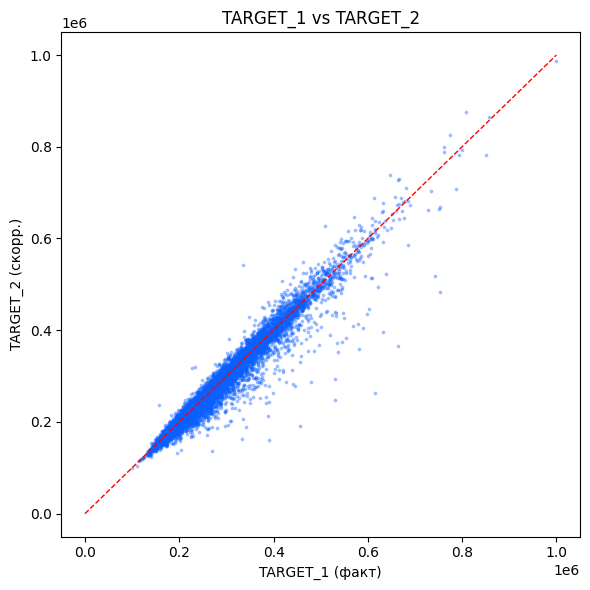

In [32]:
# Корреляция и отношение
ratio = train["TARGET_2"] / train["TARGET_1"].replace(0, np.nan)
print(f"Корреляция TARGET_1 vs TARGET_2: {train['TARGET_1'].corr(train['TARGET_2']):.4f}")
print(f"Отношение T2/T1 — медиана: {ratio.median():.3f}, "
      f"IQR: [{ratio.quantile(0.25):.3f}, {ratio.quantile(0.75):.3f}]")

# Scatter
plt.figure(figsize=(6, 6))
plt.scatter(train["TARGET_1"], train["TARGET_2"], s=3, alpha=0.3, color="#0B5FFF")
plt.plot([0, train["TARGET_1"].max()], [0, train["TARGET_1"].max()], "r--", lw=1)
plt.xlabel("TARGET_1 (факт)"); plt.ylabel("TARGET_2 (скорр.)")
plt.title("TARGET_1 vs TARGET_2")
plt.tight_layout(); plt.show()

Корреляция 0.978, отношение T2/T1 ≈ 0.991 (медиана), IQR узкий [0.97, 1.01].

То есть TARGET_2 ≈ TARGET_1, скорректированный вниз на ~1% с небольшим разбросом.

`Scatter` подтверждает: облако плотно вдоль диагонали, но с разбросом (не идеальная линия) — корректировка индивидуальна по магазинам, не глобальный множитель.

In [ ]:
# маленькие магазины по ДОЛЕ НЕДОТОРГОВКИ == 246083 у.е.

for col in ["TARGET_1", "TARGET_2"]:
    print(f"{col}: < 246083 у.е.: {(train[col] < 246083).sum()} "
          f"({(train[col] < 246083).mean()*100:.1f}%)")
    print(f"   min 5 значений: {sorted(train[col].nsmallest(5).tolist())}")

TARGET_1: < 246083 у.е.: 7459 (49.4%)
   min 5 значений: [100000.0, 109333.196540011, 114670.919804253, 116369.604819958, 116703.170394217]
TARGET_2: < 246083 у.е.: 7714 (51.1%)
   min 5 значений: [100057.205742294, 104712.496326218, 114388.8995184, 116178.077368253, 116404.026464465]


- Порог 246 083 — это медиана. TARGET_1: 49.4% магазинов ниже, ~50% выше. Не случайное число из ТЗ — это точка разделения выборки пополам. 

- Два «ценовых сегмента» из ТЗ (про недоторговку) = просто нижняя и верхняя половины по продажам.

- Минимум ровно 100_000 у обоих — подтверждает гипотезу про искусственную нижнюю границу (clipping). Дальше значения растут плавно (109k, 114k...), без скопления у пола → обрезана только пара точек на самой границе.

Значение для стратегии:

- Оба таргета почти эквивалентны по распределению (skew, диапазон идентичны). Выбор между ними — не про распределение, а про стабильность к дрейфу. TARGET_2 «скорректирован на внешние факторы» → гипотеза: он стабильнее между train/val/holdout.

- log1p — обязателен, подтверждено.

- MAPE-риск действительно низкий: «маленькие» магазины — это 100–250k, а не 1–100. Деления на крошечные числа нет → `MAPE` стабильна. Наш вывод подтверждён.

- Клиппинг прогнозов в [100_000, 1_000_000] — теперь точно нужен. Минимум = ровно 100k неслучайно.

- Сегмент < медианы вносит больше в MAPE: маленькие магазины при той же абсолютной ошибке дают больший процент. Половина выборки — «лёгкая» для `MAPE` (большие магазины), половина — «тяжёлая». Стоит смотреть `MAPE` отдельно по двум сегментам (как ТЗ намекает про недоторговку) — это покажет, где модель слабее.

- Бизнес-метрика недоторговки считается в этих же двух сегментах (< и ≥ 246083). То есть порог из метрики и порог сегментации — один и тот же. Удобно: один сплит для обеих проверок.